In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import io
import base64
from jupyter_bbox_widget import BBoxWidget
import matplotlib.patches as patches


In [2]:
def show_points(coords, labels, ax, marker_size=375):
    coords = np.array(coords)
    labels = np.array(labels)

    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]

    if len(pos_points) > 0:
        ax.scatter(
            pos_points[:, 0], pos_points[:, 1],
            color="green",
            marker="*",
            s=marker_size,
            edgecolor="white",
            linewidth=1.25
        )

    if len(neg_points) > 0:
        ax.scatter(
            neg_points[:, 0], neg_points[:, 1],
            color="red",
            marker="*",
            s=marker_size,
            edgecolor="white",
            linewidth=1.25
        )


def display_image_with_point(image, point, label):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    show_points(point, label, plt.gca())
    plt.axis("off")
    plt.show()


def show_mask(mask, ax, random_color=True):
    if random_color:
        color = np.concatenate([np.random.random(3), [0.6]])
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])

    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)

    ax.imshow(mask_image)

In [3]:
# Load the image
image = cv2.imread('data/pedestrian_day.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [4]:
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "data/sam_vit_h_4b8939.pth"
model_type = "vit_h"

device="cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)


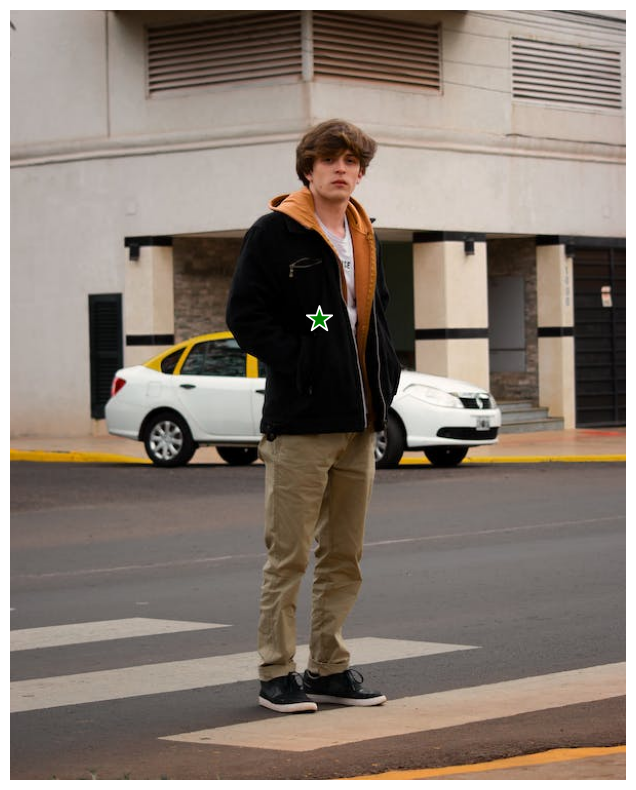

In [5]:
input_point= np.array([[300, 300]])
# points with label 1 are foeground points. These will be segmented
# points with label 0 are background points. These will not be segmented
input_label= np.array([1])

display_image_with_point(image, input_point, input_label)

In [6]:

predictor.set_image(image)

masks, scores, logits = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

[0.9554476 0.9877038 1.0080838]


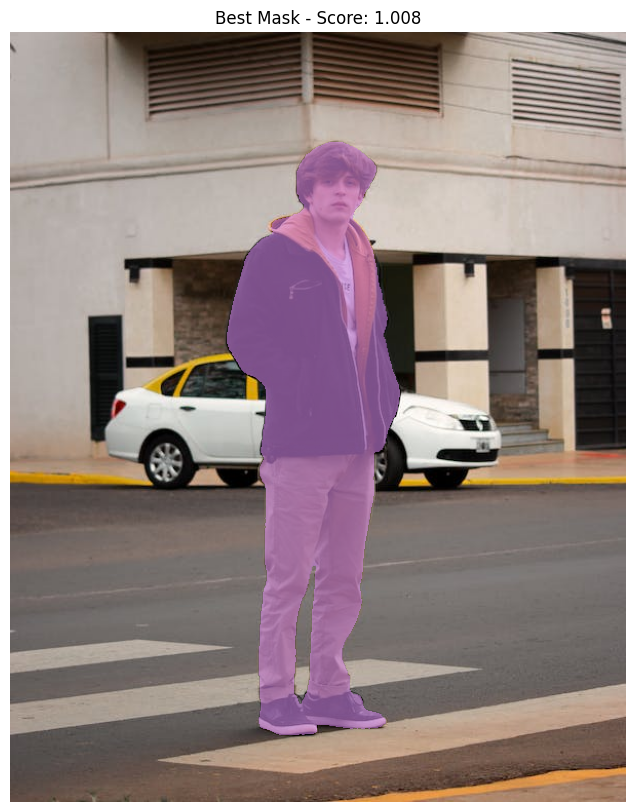

In [8]:
print(scores)

#take the index of the highest score
max_score = np.argmax(scores)


# Select the mask with the highest score
mask_with_max_score = masks[max_score]

plt.figure(figsize=(10, 10))

plt.imshow(image)
show_mask(mask_with_max_score, plt.gca())

plt.title(f"Best Mask - Score: {scores[max_score]:.3f}")

plt.axis("off")
plt.show()



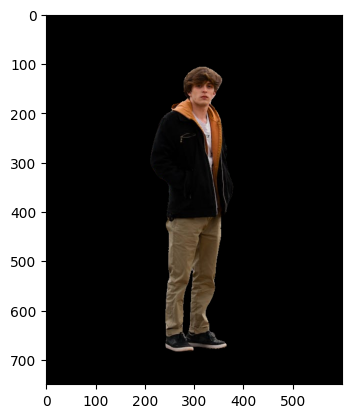

In [9]:


mask_with_max_score = mask_with_max_score.astype(bool)

#  TODO: Create a masked image
masked_image = image.copy()
masked_image[~mask_with_max_score] = 0

# Display the masked image
plt.imshow(masked_image)
plt.show()

In [12]:
background_image = cv2.imread('data/road.jpg')
background_image = cv2.cvtColor(background_image, cv2.COLOR_BGR2RGB)


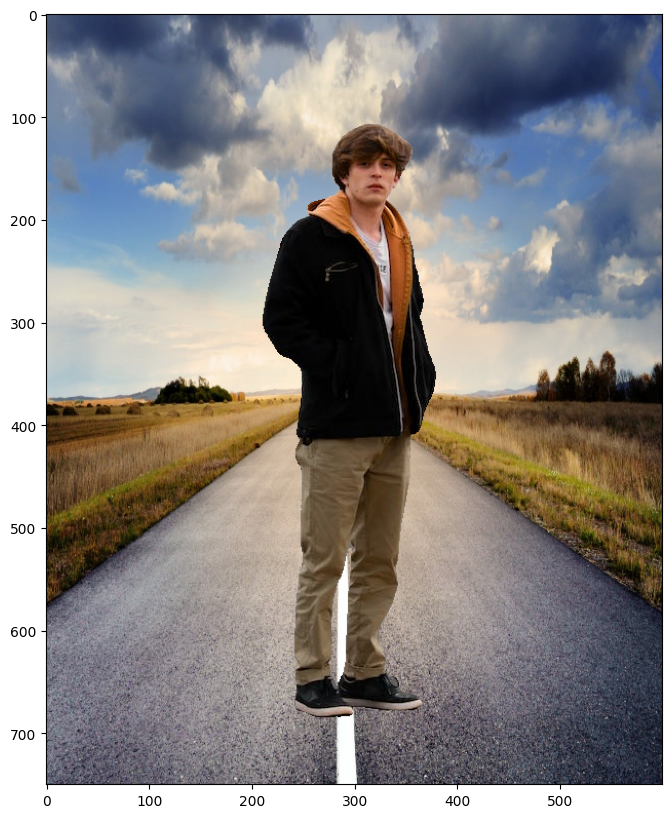

In [13]:
# Make sure the background image is the same size as the original image
background_image = cv2.resize(background_image, (image.shape[1], image.shape[0]))

mask = mask_with_max_score.astype(bool)
composite_image = image.copy()
composite_image[~mask] = background_image[~mask]

plt.figure(figsize=(10,10))

# Display the composite image
plt.imshow(composite_image)
plt.show()